In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)


df = pd.read_csv("data/silver/customer_churn_silver.csv")

df.head(20)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,5,DIAMOND,484
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,2,SILVER,206
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,1,2,DIAMOND,282
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,3,GOLD,251
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,3,GOLD,342


In [32]:
print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isna().sum())

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())


=== Dataset Overview ===
Shape: (10000, 16)

=== Data Types ===
CustomerId             int64
CreditScore            int64
Geography                str
Gender                   str
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Complain               int64
SatisfactionScore      int64
CardType                 str
PointEarned            int64
dtype: object

=== Missing Values ===
CustomerId           0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Complain             0
SatisfactionScore    0
CardType             0
PointEarned          0
dtype: int64

=== Duplicate Rows ===
0


In [33]:
drop_cols = [
    "CustomerId"
]

df = df.drop(columns=drop_cols)


In [34]:
print("\n=== Target Distribution ===")
print(df["Exited"].value_counts())

print("\n=== Target Distribution (%) ===")
print(
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


=== Target Distribution ===
Exited
0    7962
1    2038
Name: count, dtype: int64

=== Target Distribution (%) ===
Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


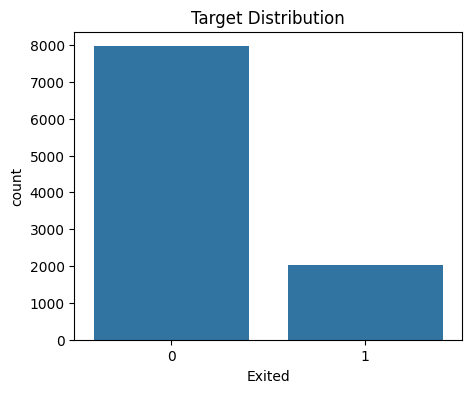

In [35]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="Exited"
)

plt.title("Target Distribution")
plt.show()

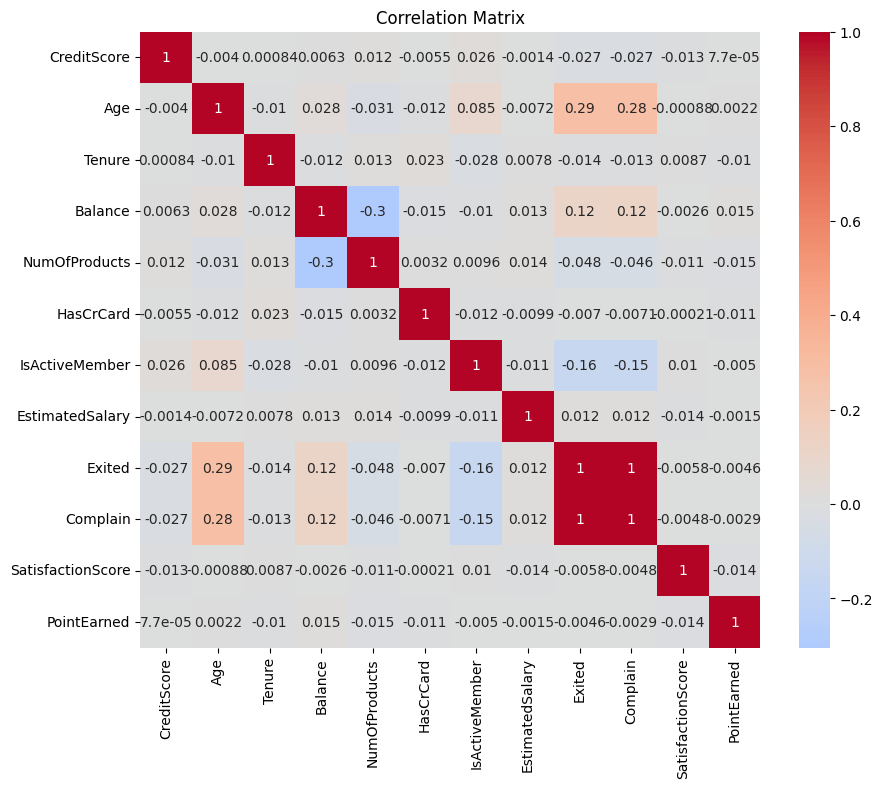

In [36]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

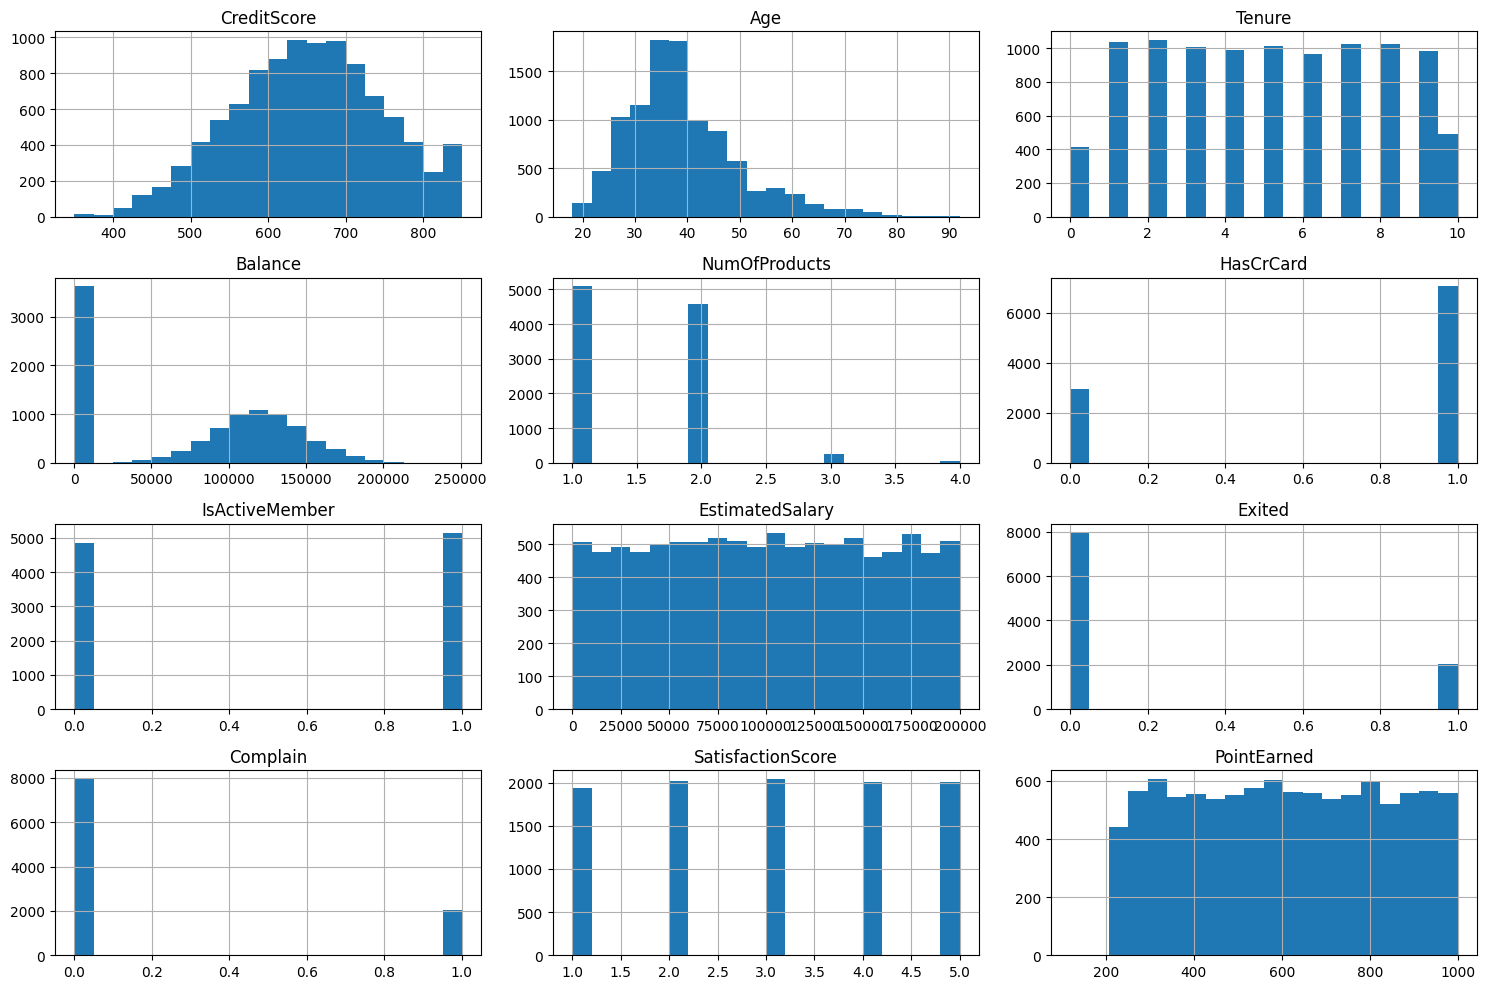

In [37]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

## Drop Leakage Feature

The `Complain` feature is removed before model training because it exhibits an extremely high correlation with the target variable (`Exited`). Including this feature would introduce target leakage, allowing the model to learn information that would not be available during real-world prediction. Removing it ensures a fair evaluation and better generalization.

In [38]:
df = df.drop(columns=["Complain"])

In [39]:
import pandas as pd
from scipy.stats import mannwhitneyu

# ============================================================
# Statistical Test (Numerical Features)
# Mann-Whitney U Test
# ============================================================

numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "SatisfactionScore",
    "PointEarned"
]

results = []

for feature in numeric_features:

    churn = df[df["Exited"] == 1][feature]
    stayed = df[df["Exited"] == 0][feature]

    statistic, p_value = mannwhitneyu(
        churn,
        stayed,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "Statistic": statistic,
        "P-value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

numeric_test = (
    pd.DataFrame(results)
      .sort_values("P-value")
      .reset_index(drop=True)
)

numeric_test

,Feature,Statistic,P-value,Significant
0,Age,11878815.0,2.780265e-230,Yes
1,NumOfProducts,6835967.0,7.279415e-36,Yes
2,Balance,9373909.5,1.168765e-28,Yes
3,CreditScore,7846429.5,2.175071e-02,Yes
4,Tenure,7955556.0,1.729583e-01,No
5,EstimatedSalary,8258306.0,2.123558e-01,No
6,SatisfactionScore,8046002.0,5.548863e-01,No
7,PointEarned,8062041.5,6.595122e-01,No


In [40]:
import pandas as pd
from scipy.stats import chi2_contingency

# ============================================================
# Statistical Test (Categorical Features)
# Chi-Square Test
# ============================================================

categorical_features = [
    "Geography",
    "Gender",
    "CardType",
    "HasCrCard",
    "IsActiveMember"
]

results = []

for feature in categorical_features:

    contingency = pd.crosstab(
        df[feature],
        df["Exited"]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    results.append({
        "Feature": feature,
        "Chi-square": chi2,
        "P-value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

categorical_test = (
    pd.DataFrame(results)
      .sort_values("P-value")
      .reset_index(drop=True)
)

categorical_test

,Feature,Chi-square,P-value,Significant
0,Geography,300.626401,5.245736e-66,Yes
1,IsActiveMember,243.694802,6.153167e-55,Yes
2,Gender,112.396554,2.925368e-26,Yes
3,CardType,5.053223,1.679411e-01,No
4,HasCrCard,0.449404,5.026182e-01,No


## Feature Engineering

In [10]:
# Binary Encoding

df["Gender"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

# One-Hot Encoding

encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

encoded = encoder.fit_transform(
    df[["Geography", "CardType"]]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(
        ["Geography", "CardType"]
    ),
    index=df.index
)

df = pd.concat(
    [
        df.drop(columns=["Geography", "CardType"]),
        encoded_df
    ],
    axis=1
)

print(df.head())
print(f"\nDataset shape: {df.shape}")

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  SatisfactionScore  PointEarned  \
0               1        101348.88       1                  2          464   
1               1        112542.58       0                  3          456   
2               0        113931.57       1                  3          377   
3               0         93826.63       0                  5          350   
4               1         79084.10       0                  5          425   

   Geography_Germany  Geography_Spain  CardType_GOLD  CardType_PLATINUM  \

In [11]:
# Split Features and Target

X = df.drop(columns=["Exited"])
y = df["Exited"]

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)

print("\nTraining target distribution")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution")
print(y_test.value_counts(normalize=True).round(3))

Training set : (8000, 16)
Testing set  : (2000, 16)

Training target distribution
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64

Testing target distribution
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


In [12]:
# Feature Scaling

scaler = StandardScaler()

numeric_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "SatisfactionScore",
    "PointEarned"
]

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Feature scaling completed.")

Feature scaling completed.


,Feature,Importance
2,Age,0.211177
5,NumOfProducts,0.121877
4,Balance,0.109858
8,EstimatedSalary,0.105581
0,CreditScore,0.103444
10,PointEarned,0.102542
3,Tenure,0.061061
9,SatisfactionScore,0.040176
7,IsActiveMember,0.036414
11,Geography_Germany,0.027187


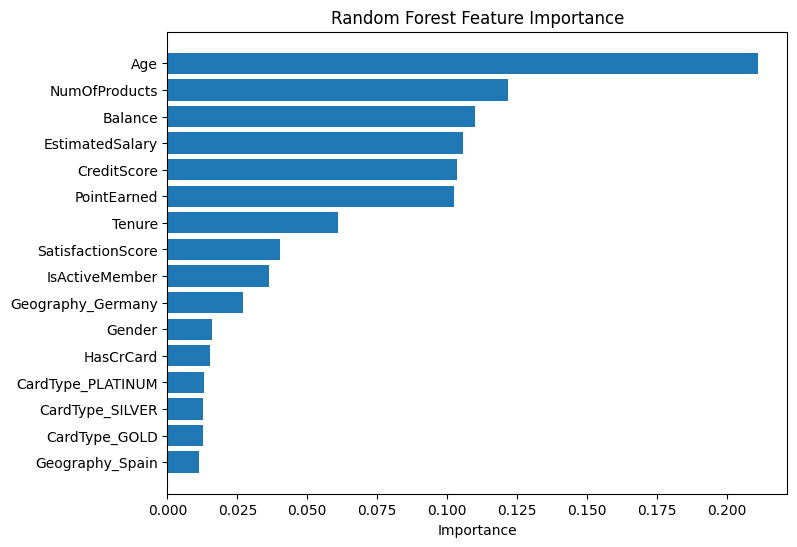

In [13]:
# Random Forest Feature Importance

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

**Baseline Model Check**

In [14]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_baseline.fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)
y_prob_rf = rf_baseline.predict_proba(X_test)[:,1]

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf),4))
print("Precision:", round(precision_score(y_test, y_pred_rf),4))
print("Recall   :", round(recall_score(y_test, y_pred_rf),4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf),4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_rf),4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))


Accuracy : 0.8695
Precision: 0.8025
Recall   : 0.4779
F1 Score : 0.5991
ROC AUC  : 0.8626

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1592
           1       0.80      0.48      0.60       408

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



**SMOTE for Data Imbalance handling**

In [16]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


In [17]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
rf_class_weight = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_class_weight.fit(X_train, y_train)

y_pred_cw = rf_class_weight.predict(X_test)
y_prob_cw = rf_class_weight.predict_proba(X_test)[:, 1]

print("Class Weight Random Forest")
print("Accuracy :", round(accuracy_score(y_test, y_pred_cw), 4))
print("Precision:", round(precision_score(y_test, y_pred_cw), 4))
print("Recall   :", round(recall_score(y_test, y_pred_cw), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_cw), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_cw), 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_cw))

comparison = pd.DataFrame({
    "Model": ["SMOTE Random Forest", "Class Weight Random Forest"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred), 4),
        round(accuracy_score(y_test, y_pred_cw), 4)
    ],
    "Precision": [
        round(precision_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred_cw), 4)
    ],
    "Recall": [
        round(recall_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred_cw), 4)
    ],
    "F1 Score": [
        round(f1_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred_cw), 4)
    ],
    "ROC AUC": [
        round(roc_auc_score(y_test, y_prob), 4),
        round(roc_auc_score(y_test, y_prob_cw), 4)
    ]
})

comparison

Class Weight Random Forest
Accuracy : 0.8645
Precision: 0.7991
Recall   : 0.4485
F1 Score : 0.5746
ROC AUC  : 0.8681

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1592
           1       0.80      0.45      0.57       408

    accuracy                           0.86      2000
   macro avg       0.84      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SMOTE Random Forest,0.8540,0.6534,0.6054,0.6285,0.8680
1,Class Weight Random Forest,0.8645,0.7991,0.4485,0.5746,0.8681


**Random Forest Model with Tuning**

In [20]:
param_dist = {
    "n_estimators": [200,300,400,500],
    "max_depth": [5,10,15,20,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log2",None],
    "bootstrap": [True, False]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="f1",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_smote,
    y_train_smote
)

print("Best Parameters")
print(random_search.best_params_)

print("\nBest CV F1")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}

Best CV F1
0.9065685563291387


In [21]:
best_rf = random_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

In [22]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_best),4))
print("Precision:", round(precision_score(y_test, y_pred_best),4))
print("Recall   :", round(recall_score(y_test, y_pred_best),4))
print("F1 Score :", round(f1_score(y_test, y_pred_best),4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob),4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))


Accuracy : 0.858
Precision: 0.6713
Recall   : 0.5956
F1 Score : 0.6312
ROC AUC  : 0.8663

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1592
           1       0.67      0.60      0.63       408

    accuracy                           0.86      2000
   macro avg       0.79      0.76      0.77      2000
weighted avg       0.85      0.86      0.85      2000



**XGBoost Model**

In [23]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos


param_dist = {
    "n_estimators": [300, 400, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1,3,5],
    "gamma": [0,0.1,0.2],
    "reg_alpha": [0,0.1,1],
    "reg_lambda": [1,2,5]
}

search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ),
    param_distributions=param_dist,
    n_iter=24,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

search_xgb.fit(X_train, y_train)

best_xgb = search_xgb.best_estimator_

print("Best Parameters:")
print(search_xgb.best_params_)

Best Parameters:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}


In [24]:
proba = best_xgb.predict_proba(X_test)[:,1]

best_threshold = 0.5
best_score = -1

for threshold in np.linspace(0.10,0.90,81):

    pred = (proba >= threshold).astype(int)

    score = f1_score(y_test,pred)

    if score > best_score:
        best_score = score
        best_threshold = threshold

xgb_pred = (proba >= best_threshold).astype(int)

print(f"Best Threshold : {best_threshold:.2f}\n")

print("Accuracy :", round(accuracy_score(y_test,xgb_pred),4))
print("Precision:", round(precision_score(y_test,xgb_pred),4))
print("Recall   :", round(recall_score(y_test,xgb_pred),4))
print("F1 Score :", round(f1_score(y_test,xgb_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test,proba),4))

print("\nClassification Report")
print(classification_report(y_test,xgb_pred))


Best Threshold : 0.62

Accuracy : 0.8545
Precision: 0.6459
Recall   : 0.6348
F1 Score : 0.6403
ROC AUC  : 0.8687

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1592
           1       0.65      0.63      0.64       408

    accuracy                           0.85      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



In [25]:
baseline_pred = y_pred_rf
rf_pred_best = y_pred_best
xgb_pred_final = xgb_pred

comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Best Random Forest",
        "Best XGBoost"
    ],
    "Accuracy": [
        round(accuracy_score(y_test, baseline_pred), 4),
        round(accuracy_score(y_test, rf_pred_best), 4),
        round(accuracy_score(y_test, xgb_pred_final), 4)
    ],
    "F1 Score": [
        round(f1_score(y_test, baseline_pred), 4),
        round(f1_score(y_test, rf_pred_best), 4),
        round(f1_score(y_test, xgb_pred_final), 4)
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Baseline Random Forest,0.8695,0.5991
1,Best Random Forest,0.8580,0.6312
2,Best XGBoost,0.8545,0.6403
